In [28]:
import pandas as pd 
import numpy as np 
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram
import matplotlib.pyplot as plt
from Transformers import *
from sklearn.pipeline import Pipeline, FeatureUnion
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans,DBSCAN
from sklearn.metrics import silhouette_score

In [3]:
df=pd.read_csv("data/CleanedKaggle/financial_loan_cleaned.csv") 

preprocessing danych

In [4]:
preprocessor = getPipeline()
np_preprocessed = preprocessor.fit_transform(df)
np_preprocessed.shape

(38576, 33)

In [5]:
df_preprocessed = pd.DataFrame(np_preprocessed, columns=preprocessor.get_feature_names_out(df.columns.tolist()))
# usuwamy basic_cat__loan_status_Fully Paid i ct_onehot__job__title_categorized_Other z uwagi na wysoką korelację z innymi zmiennymi, gdzie ta korelacja
# wynika ze wspólnego źródła danych (jakiegoś faktu) dla tych zmiennych
df_preprocessed.drop(columns=['basic_cat__loan_status_Fully Paid', 'ct_onehot__job__title_categorized_Other'], inplace=True)

In [6]:
df_preprocessed.head()

,ct_onehot__job__title_categorized_Education,ct_onehot__job__title_categorized_Energy/Utilities,ct_onehot__job__title_categorized_Finance,ct_onehot__job__title_categorized_Government/Civil Service,ct_onehot__job__title_categorized_Healthcare,ct_onehot__job__title_categorized_Legal/Law,ct_onehot__job__title_categorized_Manufacturing/Engineering,ct_onehot__job__title_categorized_Military,ct_onehot__job__title_categorized_Retail/Hospitality,ct_onehot__job__title_categorized_Self-Employed,...,basic_num__annual_income,basic_num__emp_years,basic_num__sub_grade_numeric,basic_cat__home_ownership_OTHER,basic_cat__home_ownership_OWN,basic_cat__home_ownership_RENT,basic_cat__loan_status_Current,basic_cat__verification_status_Source Verified,basic_cat__verification_status_Verified,basic_cat__term_months_60
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.616624,-1.396331,0.442734,0.0,0.0,1.0,0.0,1.0,0.0,1.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.336655,1.129782,1.471335,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.305548,-0.273614,0.589677,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,-0.429978,-1.396331,-0.585867,0.0,0.0,0.0,0.0,1.0,0.0,1.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.207729,1.410461,-1.467525,0.0,0.0,0.0,0.0,0.0,1.0,0.0


<Axes: >

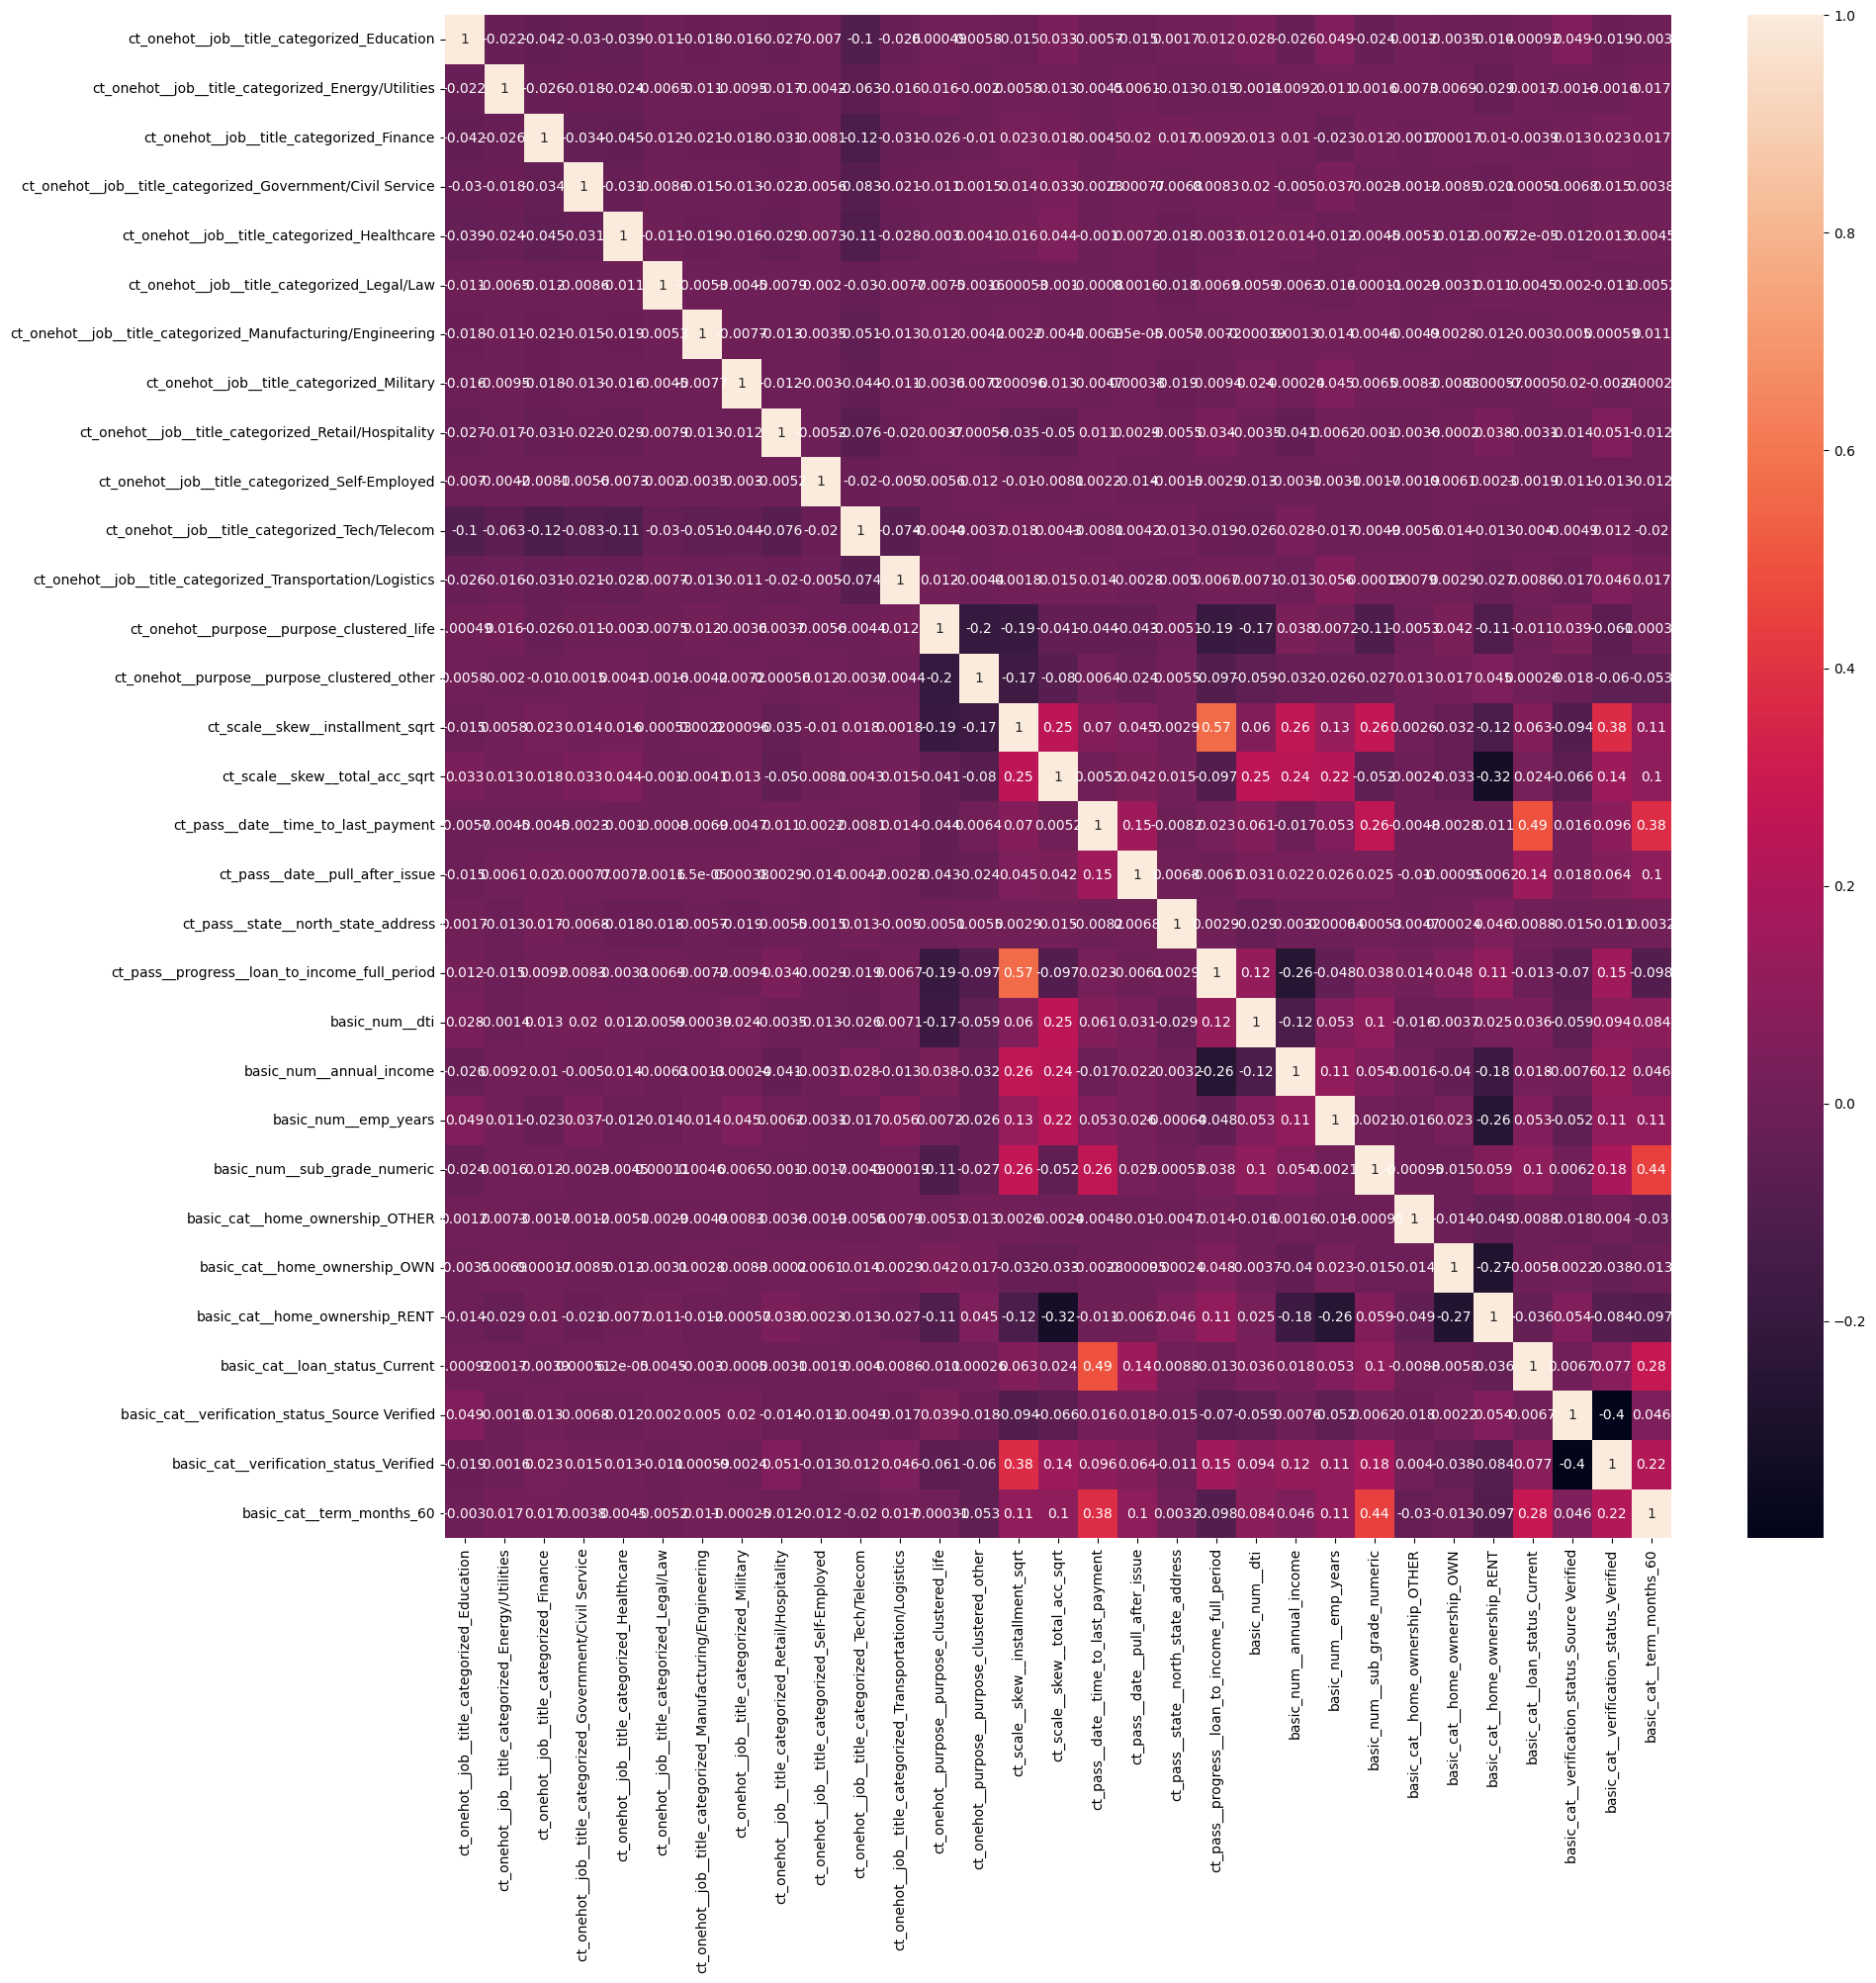

In [7]:
plt.figure(figsize=(20,20))
sns.heatmap(df_preprocessed.corr(), annot=True)

## AgglomerativeClustering

## Kmeans

In [27]:
def KMeans_plotter(X, lower_bound=2,upper_bound=20):
    if lower_bound<2: 
        raise ValueError("BROOOOOO")
    inertia_list=[]
    silhouette_list=[]
    for i in range(lower_bound,upper_bound+1): 
        k=KMeans(n_clusters=i,random_state=42)
        k.fit(X) 
        predicted=k.predict(X)
        inertia_list.append(k.inertia_)
        silhouette_list.append(silhouette_score(X,predicted)) 



    x_cord=np.arange(lower_bound,upper_bound+1)
    fig, ax = plt.subplots(2, 1, figsize=(6, 8))
    
    ax[0].scatter(x=x_cord, y=inertia_list)
    ax[0].plot(x_cord, inertia_list)
    ax[0].set_title('Inertia')
    ax[0].grid()


    ax[1].scatter(x=x_cord, y=silhouette_list)
    ax[1].plot(x_cord, silhouette_list)
    ax[1].set_title('Silhouette')
    ax[1].grid()


    plt.tight_layout()
    plt.show()


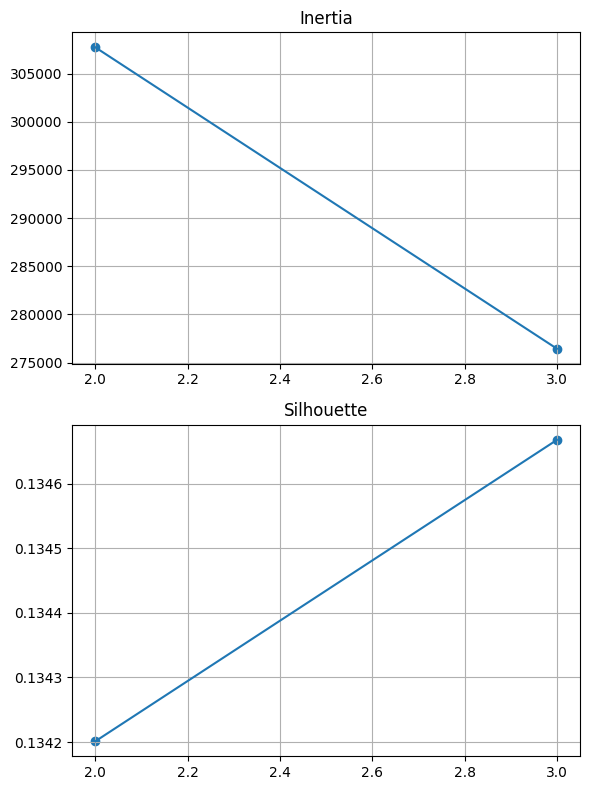

In [26]:
KMeans_plotter(2,20)

## Kmedoids

## DB SCAN 

In [55]:
def DBscanner(X,params_list):
    if len(params_list)==0: 
        raise ValueError("WOW") 
    silhouette_list=[]
    for param in params_list: 
        db=DBSCAN(**param) 
        predicted=db.fit_predict(X) 
        if len(predicted)==1: 
            print('Outliers') 
            silhouette_list.append(0)
        else:
            silhouette_list.append(silhouette_score(X,predicted)) 
        
    param_list_string=[f'param_nr_{i}' for i in range(len(params_list))]

    plt.scatter(x=param_list_string,y=silhouette_list)
    plt.title('Silhouette score') 
    plt.grid() 
    plt.tight_layout() 
    plt.show()

In [56]:
params_list = [
    {"eps": 1, "min_samples": 5},
    {"eps": 2, "min_samples": 10},
    {"eps": 3, "min_samples": 5}
]

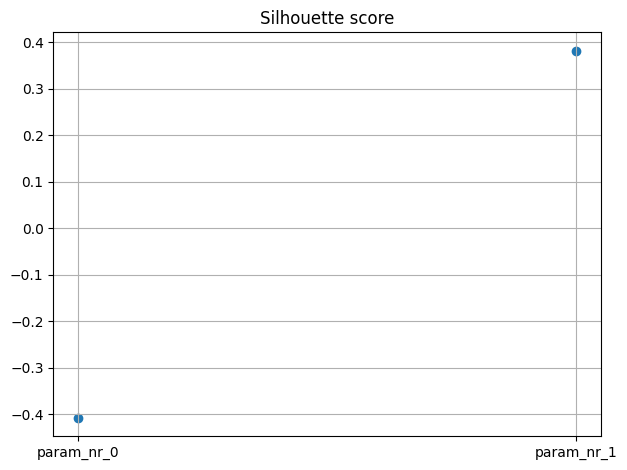

In [57]:
DBscanner(df_preprocessed, params_list)

## Gaussian Mixture Models 

## Mean shift 

## BIRCH